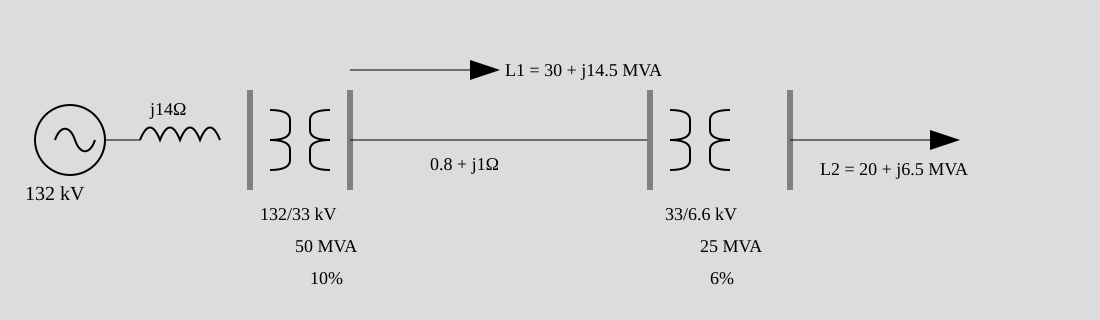

In [1]:
# TEST CELL
from myst_nb import glue
from IPython.display import SVG

svg = """
<svg xmlns="http://www.w3.org/2000/svg" viewBox="0 0 1100 320">
  <rect width="100%" height="100%" fill="#dcdcdc"/>

  <!-- Generator -->
  <circle cx="70" cy="140" r="35" fill="none" stroke="black" stroke-width="2"/>
  <path d="M55 140 c5 -15 15 -15 20 0 s15 15 20 0" fill="none" stroke="black" stroke-width="2"/>
  <text x="25" y="200" font-size="20">132 kV</text>

  <!-- Reactance -->
  <line x1="105" y1="140" x2="140" y2="140" stroke="black"/>
  <path d="M140 140 q10 -25 20 0 q10 -25 20 0 q10 -25 20 0 q10 -25 20 0"
        fill="none" stroke="black" stroke-width="2"/>
  <text x="150" y="115" font-size="18">j14Ω</text>

  <!-- Transformer 1 -->
  <line x1="250" y1="90" x2="250" y2="190" stroke="gray" stroke-width="6"/>
  <path d="M270 110 q20 0 20 10 v10 q0 10 -20 10 q20 0 20 10 v10 q0 10 -20 10"
        fill="none" stroke="black" stroke-width="2"/>
  <path d="M330 110 q-20 0 -20 10 v10 q0 10 20 10 q-20 0 -20 10 v10 q0 10 20 10"
        fill="none" stroke="black" stroke-width="2"/>
  <line x1="350" y1="90" x2="350" y2="190" stroke="gray" stroke-width="6"/>

  <text x="260" y="220" font-size="18">132/33 kV</text>
  <text x="295" y="252" font-size="18">50 MVA</text>
  <text x="310" y="284" font-size="18">10%</text>

  <!-- Bus -->
  <line x1="350" y1="140" x2="650" y2="140" stroke="black"/>

  <!-- Load L1 -->
  <line x1="350" y1="70" x2="470" y2="70" stroke="black"/>
  <polygon points="470,60 500,70 470,80" fill="black"/>
  <text x="505" y="76" font-size="18">L1 = 30 + j14.5 MVA</text>

  <!-- Line impedance -->
  <text x="430" y="170" font-size="18">0.8 + j1Ω</text>

  <!-- Transformer 2 -->
  <line x1="650" y1="90" x2="650" y2="190" stroke="gray" stroke-width="6"/>
  <path d="M670 110 q20 0 20 10 v10 q0 10 -20 10 q20 0 20 10 v10 q0 10 -20 10"
        fill="none" stroke="black" stroke-width="2"/>
  <path d="M730 110 q-20 0 -20 10 v10 q0 10 20 10 q-20 0 -20 10 v10 q0 10 20 10"
        fill="none" stroke="black" stroke-width="2"/>
  <line x1="790" y1="90" x2="790" y2="190" stroke="gray" stroke-width="6"/>

  <text x="665" y="220" font-size="18">33/6.6 kV</text>
  <text x="700" y="252" font-size="18">25 MVA</text>
  <text x="710" y="284" font-size="18">6%</text>

  <!-- Load L2 -->
  <line x1="790" y1="140" x2="930" y2="140" stroke="black"/>
  <polygon points="930,130 960,140 930,150" fill="black"/>
  <text x="820" y="175" font-size="18">L2 = 20 + j6.5 MVA</text>
</svg>
"""

glue("last_flyt", SVG(svg), display=True)

In [24]:
0.29 * 50

14.499999999999998

In [3]:
import numpy as np
import pandapower as pp

Først må vi se hvilke verdier vi har her:
- Systembase: S_base er 50 MVA
- Et ekstern nett på 132 kV
- tilhørende $X_s$ = j14
- 50 Mva trafo på 0.1
- 25 MVA trafo på 0.06
- Linje 0.8 + j1
- L1 30 + j14.5 MVA
- L2 20 + j6.5 MVA
- P,Q, bus på 20 + j6.5 MVA

In [4]:
#create empty net
net = pp.create_empty_network(sn_mva=50)

- bus0: generatorens interne spenning E
- bus1: terminalspenning V
- Ext_grid = hold intern spenning til 1 pu

In [5]:
Z_base = 132**2/50
Z_base

348.48

In [6]:
z_pu_gen = np.round((14/Z_base),4)
print(z_pu_gen)

0.0402


In [7]:
z_pu_line = (0.8+1j)/(33**2/50)
z_pu_line

(0.03673094582185491+0.04591368227731864j)

In [8]:
bus0 = pp.create_bus(net, vn_kv=132)
bus1 = pp.create_bus(net, vn_kv=132)

Grid = pp.create_ext_grid(net, bus=bus0, vm_pu=1.0, name="Grid Connection")

pp.create_impedance(
    net,
    from_bus=bus0,
    to_bus=bus1,
    rft_pu=0.0,
    xft_pu=z_pu_gen,
    sn_mva=50
)

np.int64(0)

https://pandapower.readthedocs.io/en/latest/std_types/manage.html

In [9]:
#create buses
bus1 = pp.create_bus(net, vn_kv=132., name="Bus 1")
bus2 = pp.create_bus(net, vn_kv=33, name="Bus2")
bus3 = pp.create_bus(net, vn_kv=33, name="Bus3")
bus4 = pp.create_bus(net, vn_kv=6.6, name='Bus4')

In [10]:
#pp.available_std_types(net, element="trafo")

In [11]:
print(net.std_types["trafo"].keys())

dict_keys(['160 MVA 380/110 kV', '100 MVA 220/110 kV', '63 MVA 110/20 kV', '40 MVA 110/20 kV', '25 MVA 110/20 kV', '63 MVA 110/10 kV', '40 MVA 110/10 kV', '25 MVA 110/10 kV', '0.25 MVA 20/0.4 kV', '0.4 MVA 20/0.4 kV', '0.63 MVA 20/0.4 kV', '0.25 MVA 10/0.4 kV', '0.4 MVA 10/0.4 kV', '0.63 MVA 10/0.4 kV'])


In [12]:
T1 = pp.create_transformer_from_parameters(
    net,
    hv_bus=bus1,
    lv_bus=bus2,
    sn_mva=0.5,
    vn_hv_kv=132,
    vn_lv_kv=33,
    vk_percent=10,
    vkr_percent=0.5,
    pfe_kw=1.0,
    i0_percent=0.1,
    name = 'trafo1'
)

T2 = pp.create_transformer_from_parameters(
    net,
    hv_bus=bus3,
    lv_bus=bus4,
    sn_mva=25,
    vn_hv_kv=33,
    vn_lv_kv=6.6,
    vk_percent=6,
     vkr_percent=0.5,
    pfe_kw=1.0,
    i0_percent=0.1,
    name='trafo2'
)

https://pandapower.readthedocs.io/en/latest/elements/trafo.html

Oversikt over standardtyper:

https://pandapower.readthedocs.io/en/latest/std_types.html

Håndtering av standardtyper:

https://pandapower.readthedocs.io/en/latest/std_types/manage.html

https://pandapower.readthedocs.io/en/latest/elements/line.html

In [13]:
#pp.available_std_types(net, element="line")

In [14]:
#create branch elements
Line = pp.create_impedance(
    net,
    from_bus=bus2,
    to_bus=bus3,
    rft_pu=0.037,
    xft_pu=0.166,
    sn_mva=50
)

#create bus elements
Load1 = pp.create_load(net, bus=bus2, p_mw=30, q_mvar=14.5, name="Load1")
Load2 = pp.create_load(net, bus=bus4, p_mw=20, q_mvar=6.5, name="Load2")


In [15]:
pp.runpp(
    net,
    algorithm="bfsw",
    max_iteration=40
)

In [16]:
net.res_bus

,vm_pu,va_degree,p_mw,q_mvar
0,1.0,0.0,0.0,0.0
1,1.0,0.0,0.0,0.0
2,NaN,NaN,0.0,0.0
3,NaN,NaN,0.0,0.0
4,NaN,NaN,0.0,0.0
5,NaN,NaN,0.0,0.0


In [17]:
net.converged

True

In [22]:
import pandapower as pp

# create network
net = pp.create_empty_network(sn_mva=50)

# buses
bus1 = pp.create_bus(net, vn_kv=1.0, name="Bus 1")
bus2 = pp.create_bus(net, vn_kv=1.0, name="Bus 2")
bus3 = pp.create_bus(net, vn_kv=1.0, name="Bus 3")

# slack bus (V1 = 1∠0)
pp.create_ext_grid(
    net,
    bus=bus1,
    vm_pu=1.0,
    va_degree=0
)

# generator reactance j0.14 pu
pp.create_impedance(
    net,
    from_bus=bus1,
    to_bus=bus2,
    rft_pu=0.0,
    xft_pu=0.14,
    sn_mva=50
)

# line impedance 0.037 + j0.166 pu
pp.create_impedance(
    net,
    from_bus=bus2,
    to_bus=bus3,
    rft_pu=0.037,
    xft_pu=0.166,
    sn_mva=50
)

# load at bus 2
pp.create_load(
    net,
    bus=bus2,
    p_mw=0.60 * 50,
    q_mvar=0.29 * 50,
    name="L1"
)

# load at bus 3
pp.create_load(
    net,
    bus=bus3,
    p_mw=0.38 * 50,
    q_mvar=0.125 * 50,
    name="L2"
)

# load flow
pp.runpp(
    net,
    algorithm="bfsw",
    max_iteration=20
)

# results
print(net.res_bus[["vm_pu", "va_degree"]])

      vm_pu  va_degree
0  1.000000   0.000000
1  0.920275  -8.641634
2  0.878228 -12.789255
